In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import spacy
import unicodedata
import seaborn as sns

In [ ]:
nlp = spacy.load("pt_core_news_lg", disable=["ner", "parser"])

def data_preprocessing(df, column_name):
    try:
        from unidecode import unidecode as _unidecode
        def normalize_unidecode(text: str) -> str:
            return _unidecode(text)
    except Exception:
        def normalize_unidecode(text: str) -> str:
            # Fallback razoável: remove diacríticos
            return ''.join(
                c for c in unicodedata.normalize('NFKD', text)
                if not unicodedata.combining(c)
            )
        
    def preprocess_text_pt_single(text: str) -> str:
        if not isinstance(text, str):
            return ""
        # 1. remover quebras e normalizar espaços
        text = re.sub(r'\s+', ' ', text.strip())
        # 2. remover HTML, URLs e emails
        text = re.sub(r'<[^>]+>', '', text)
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)
        text = re.sub(r'\S+@\S+', '', text)
        # 3. normalizar acentos (unidecode ou fallback)
        text = normalize_unidecode(text)
        # 4. remover tokens alfanuméricos tipo Q12, A1, C3
        text = re.sub(r'\b[a-zA-Z]*\d+[a-zA-Z]*\b', ' ', text)
        # 5. remover pontuação solta (mantém hífens e apóstrofos dentro de palavras se existirem)
        text = re.sub(r'[^\w\s\-\']', ' ', text)
        # 6. normalizar espaços de novo
        text = re.sub(r'\s+', ' ', text).strip()
        return text.lower()
    
    def preprocess_series_spacy(texts, batch_size=256, n_process=1):
        """Limpa + lematiza + remove pontuação."""
        cleaned = (preprocess_text_pt_single(t) for t in texts)
        results = []
        for doc in nlp.pipe(cleaned, batch_size=batch_size, n_process=n_process):
            tokens = [
                tok.lemma_.lower()
                for tok in doc
                if not tok.is_punct
                and not tok.is_space
                and not tok.like_num
                and len(tok.text) > 2
            ]
            results.append(" ".join(tokens))
        return results
    
    
    df['CLEAN_TEXT'] = preprocess_series_spacy(df[column_name])
    df['CLEAN_TEXT'] = (
        df['CLEAN_TEXT']
        .fillna("")        # remove NaN
        .astype(str)       # garante string
    )
    df.rename(columns={column_name: 'UNCLEAN_TEXT'}, inplace=True)
    df['UNCLEAN_TEXT'] = (
        df['UNCLEAN_TEXT']
        .fillna("")
        .astype(str)
    )
    return df

# (1) TweetEmotionsPTBR

In [14]:
df = pd.read_excel('../data/03_TweetEmotionsPTBR.xlsx')
df.drop(columns=['alegria',	'tristeza',	'raiva', 'medo', 'nojo', 'surpresa', 'confianca', 'antecipacao'], inplace=True)
print(df.shape)
df.head(3)

(12678, 2)


,texto,sentimento
0,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,alegria
1,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",decepção
2,"A franquia continua ativa, com o desenvolvimen...",decepção


In [15]:
df.drop_duplicates(inplace=True)
df = data_preprocessing(df, 'texto')
df.rename(columns={"sentimento": 'EMOTION'}, inplace=True)
print(df.shape)
df.head(3)

(12420, 3)


,UNCLEAN_TEXT,EMOTION,CLEAN_TEXT
0,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,alegria,que jubilo incalculavel ver todo meu querido q...
1,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",decepção,sapontamentoir senhor arrancar meu coracao qua...
2,"A franquia continua ativa, com o desenvolvimen...",decepção,franquia continuar ativo com desenvolvimento j...


In [16]:
n_nan = df['CLEAN_TEXT'].isna().sum()

n_empty = (df['CLEAN_TEXT'].str.strip() == '').sum()

print(f'Textos NaN: {n_nan}')
print(f'Textos vazios ou em branco: {n_empty}')
print(f'Total problemáticos: {n_nan + n_empty}')

df = df.dropna(subset=['CLEAN_TEXT'])
df = df[df['CLEAN_TEXT'].str.strip() != '']

print(df.shape)

Textos NaN: 0
Textos vazios ou em branco: 1
Total problemáticos: 1
(12419, 3)


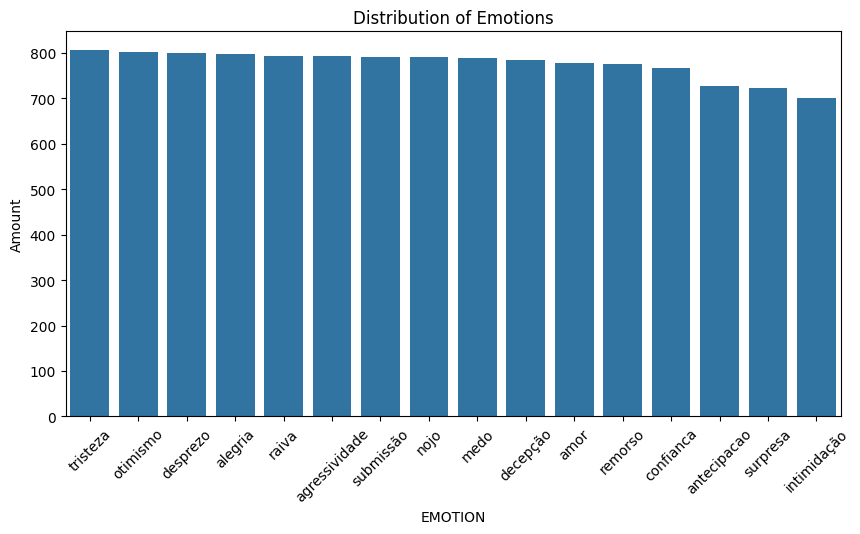

In [17]:
plt.figure(figsize=(10, 5))
sns.barplot(x=df.EMOTION.value_counts().index, y=df.EMOTION.value_counts().values)
plt.xticks(rotation=45)
plt.ylabel("Amount")
plt.title("Distribution of Emotions")
plt.show()

In [18]:
df.to_csv("../data/treated/tweet_emotions_ptbr_treated.csv", index=False)

# (2) GoEmotions

In [19]:
df_1 = pd.read_csv('../data/05_goemotions_1_pt.csv')
df_2 = pd.read_csv('../data/05_goemotions_2_pt.csv')
df_3 = pd.read_csv('../data/05_goemotions_3_pt.csv')

df = pd.concat([df_1, df_2, df_3])
df.drop(columns=['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id'], inplace=True)

print(df.shape)
df.head(3)

(211225, 30)


,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,texto
0,False,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,Aquele jogo doeu.
1,True,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,>sexualidade não deve ser uma categoria de agr...
2,False,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,"Você faz certo, se você não se importa, então ..."


In [20]:
df.columns

Index(['example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance',
       'approval', 'caring', 'confusion', 'curiosity', 'desire',
       'disappointment', 'disapproval', 'disgust', 'embarrassment',
       'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
       'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse',
       'sadness', 'surprise', 'neutral', 'texto'],
      dtype='object')

In [21]:
df.drop_duplicates(inplace=True)
df = data_preprocessing(df, 'texto')
print(df.shape)
df.head(3)

(156007, 31)


,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,UNCLEAN_TEXT,CLEAN_TEXT
0,False,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,Aquele jogo doeu.,aquele jogo doeu
1,True,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,>sexualidade não deve ser uma categoria de agr...,sexualidade nao dever ser um categoria agrupam...
2,False,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,"Você faz certo, se você não se importa, então ...",voce fazer certo voce nao importar entao foda-se


In [22]:
n_nan = df['CLEAN_TEXT'].isna().sum()

n_empty = (df['CLEAN_TEXT'].str.strip() == '').sum()

print(f'Textos NaN: {n_nan}')
print(f'Textos vazios ou em branco: {n_empty}')
print(f'Total problemáticos: {n_nan + n_empty}')

df = df.dropna(subset=['CLEAN_TEXT'])
df = df[df['CLEAN_TEXT'].str.strip() != '']

print(df.shape)

Textos NaN: 0
Textos vazios ou em branco: 56
Total problemáticos: 56
(155951, 31)


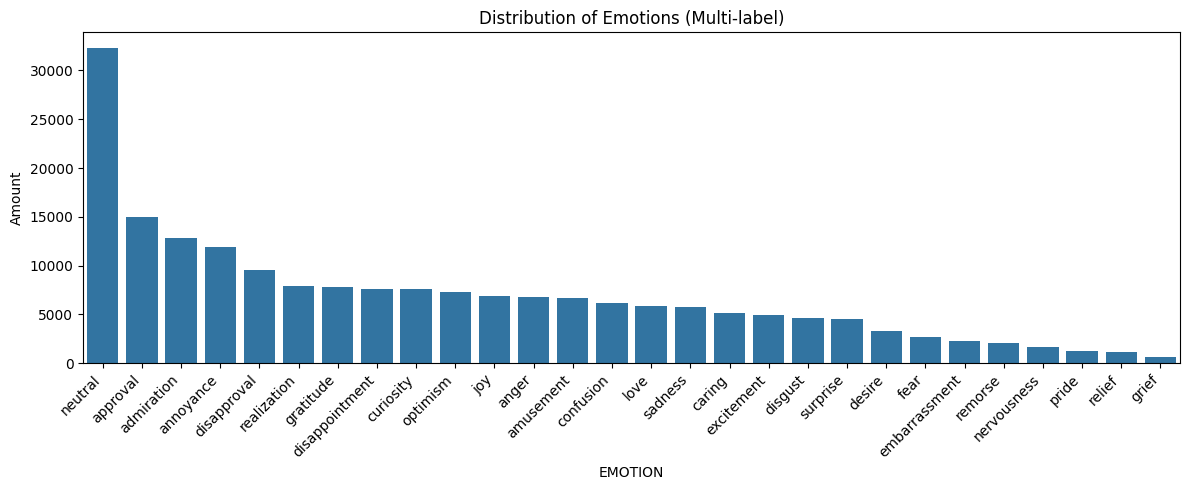

In [23]:
emotions = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

emotion_counts = df[emotions].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(
    x=emotion_counts.index,
    y=emotion_counts.values
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Amount")
plt.xlabel("EMOTION")
plt.title("Distribution of Emotions (Multi-label)")
plt.tight_layout()
plt.show()

In [24]:
df.to_csv("../data/treated/go_emotions_treated.csv", index=False)

# (3) PlayStoreReviews

In [25]:
df = pd.read_csv('../data/08_PlayStoreReviews.csv')
df.drop(columns=['reviewId', 'app_name'], inplace=True)
print(df.shape)
df.head(3)

(3011, 3)


,content,sentiment_polarity,sentiment
0,app shope razoá apes fácil utiliz apresent alg...,positive,sadness
1,app bem otimiz fácil visual produt ped rastrei...,positive,sadness
2,app bom prát fácil entend porém algum vend man...,positive,sadness


In [26]:
df.drop_duplicates(inplace=True)
df = data_preprocessing(df, 'content')
df.rename(columns={"sentiment": 'EMOTION'}, inplace=True)
df.rename(columns={"sentiment_polarity": 'SENTIMENT'}, inplace=True)
print(df.shape)
df.head(3)

(3011, 4)


,UNCLEAN_TEXT,SENTIMENT,EMOTION,CLEAN_TEXT
0,app shope razoá apes fácil utiliz apresent alg...,positive,sadness,app shope razoa apes facil utiliz apresent alg...
1,app bem otimiz fácil visual produt ped rastrei...,positive,sadness,app bem otimiz facil visual produt ped rastrar...
2,app bom prát fácil entend porém algum vend man...,positive,sadness,app bom prat facil entend porem algum vend man...


In [27]:
n_nan = df['CLEAN_TEXT'].isna().sum()

n_empty = (df['CLEAN_TEXT'].str.strip() == '').sum()

print(f'Textos NaN: {n_nan}')
print(f'Textos vazios ou em branco: {n_empty}')
print(f'Total problemáticos: {n_nan + n_empty}')

df = df.dropna(subset=['CLEAN_TEXT'])
df = df[df['CLEAN_TEXT'].str.strip() != '']

print(df.shape)

Textos NaN: 0
Textos vazios ou em branco: 1
Total problemáticos: 1
(3010, 4)


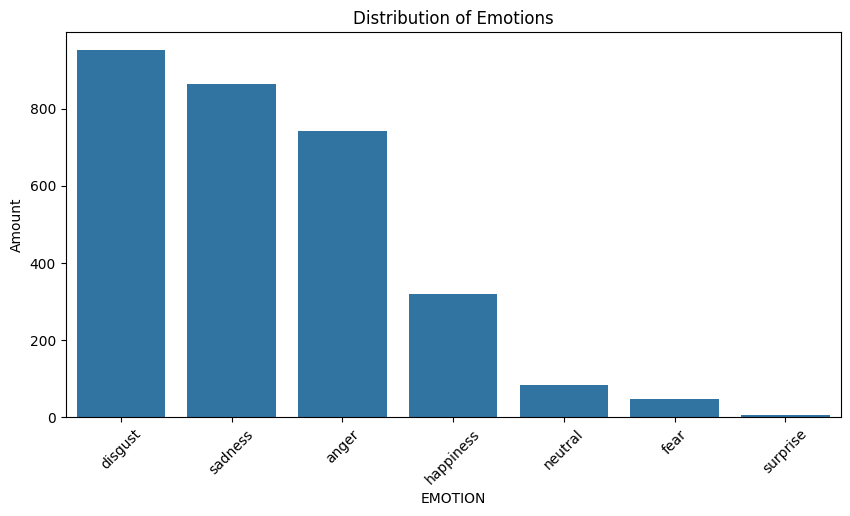

In [28]:
plt.figure(figsize=(10, 5))
sns.barplot(x=df.EMOTION.value_counts().index, y=df.EMOTION.value_counts().values)
plt.xticks(rotation=45)
plt.ylabel("Amount")
plt.title("Distribution of Emotions")
plt.show()

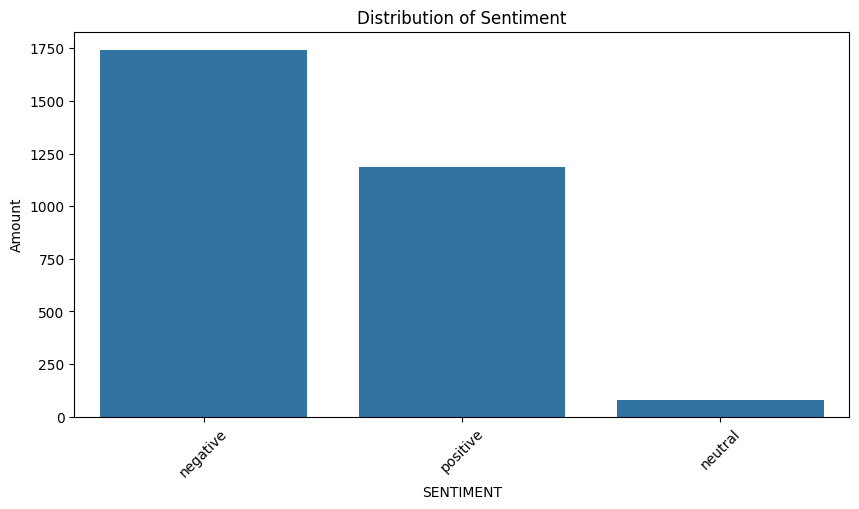

In [29]:
plt.figure(figsize=(10, 5))
sns.barplot(x=df.SENTIMENT.value_counts().index, y=df.SENTIMENT.value_counts().values)
plt.xticks(rotation=45)
plt.ylabel("Amount")
plt.title("Distribution of Sentiment")
plt.show()

In [30]:
df.to_csv("../data/treated/play_store_reviews_treated.csv", index=False)